### Setting up the model and dataset

In [2]:
import pandas as pd
import torch
import torch.nn as nn
from transformers import BertTokenizer, BertModel, AdamW, get_linear_schedule_with_warmup
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import DataLoader, Dataset
from sklearn.metrics import precision_recall_fscore_support, accuracy_score
import numpy as np

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

df = pd.read_csv('finaldataset_with_sets.csv') 

# Tokenization
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

def tokenize_function(text):
    return tokenizer(text, padding='max_length', truncation=True, return_tensors="pt")

df['input_ids'] = df['transcript'].apply(lambda x: tokenize_function(x)['input_ids'].squeeze())
df['attention_mask'] = df['transcript'].apply(lambda x: tokenize_function(x)['attention_mask'].squeeze())

# Dataset preparation
class TextDataset(Dataset):
    def __init__(self, dataframe):
        self.dataframe = dataframe

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        input_ids = self.dataframe.iloc[idx]['input_ids']
        attention_mask = self.dataframe.iloc[idx]['attention_mask']
        label = self.dataframe.iloc[idx]['label']
        return input_ids, attention_mask, label

train_df = df[df['set'] == 'training']
val_df = df[df['set'] == 'validation']

train_dataset = TextDataset(train_df)
val_dataset = TextDataset(val_df)

train_dataloader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=16)


/opt/anaconda3/lib/python3.12/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [3]:
class TextClassificationModel(nn.Module):
    def __init__(self, num_classes=5, dropout_rate=0.5):
        super(TextClassificationModel, self).__init__()
        self.bert = BertModel.from_pretrained('bert-base-uncased')
        self.dropout = nn.Dropout(dropout_rate)
        self.fc = nn.Linear(self.bert.config.hidden_size, num_classes)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = outputs[1]  
        dropout_output = self.dropout(pooled_output)
        return self.fc(dropout_output)

text_model = TextClassificationModel(num_classes=5, dropout_rate=0.5).to(device)

# Optimizer and Scheduler
optimizer = AdamW(text_model.parameters(), lr=2e-5, weight_decay=0.01)
total_steps = len(train_dataloader) * 10 
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0, num_training_steps=total_steps)

# Class Weights
labels = train_df['label'].values
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(labels), y=labels)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

# Loss Function
class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2, logits=False, reduce=True):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.logits = logits
        self.reduce = reduce

    def forward(self, inputs, targets):
        BCE_loss = nn.functional.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-BCE_loss)
        F_loss = self.alpha * (1 - pt) ** self.gamma * BCE_loss

        if self.reduce:
            return torch.mean(F_loss)
        else:
            return F_loss

loss_fn = FocalLoss(logits=True).to(device)

A parameter name that contains `beta` will be renamed internally to `bias`. Please use a different name to suppress this warning.
A parameter name that contains `gamma` will be renamed internally to `weight`. Please use a different name to suppress this warning.
A parameter name that contains `beta` will be renamed internally to `bias`. Please use a different name to suppress this warning.
A parameter name that contains `gamma` will be renamed internally to `weight`. Please use a different name to suppress this warning.
A parameter name that contains `beta` will be renamed internally to `bias`. Please use a different name to suppress this warning.
A parameter name that contains `gamma` will be renamed internally to `weight`. Please use a different name to suppress this warning.
A parameter name that contains `beta` will be renamed internally to `bias`. Please use a different name to suppress this warning.
A parameter name that contains `gamma` will be renamed internally to `weight`. Pl

### Late-Fusion

In [7]:
text_logits = np.load('text_logits_final_3.npy')

In [9]:
visual_logits = np.load('visual_logits_val.npy')
visual_logits = np.squeeze(visual_logits, axis=1)
print(f"New shape of visual_logits: {visual_logits.shape}")  


New shape of visual_logits: (100, 5)


In [11]:
alpha = 0.5 

combined_logits = alpha * visual_logits + (1 - alpha) * text_logits
combined_predictions = np.argmax(combined_logits, axis=1)


In [13]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

true_labels = val_df['label'].values

# Calculate the accuracy
accuracy = accuracy_score(true_labels, combined_predictions)

# Calculate precision, recall, and f1-score
precision, recall, f1, _ = precision_recall_fscore_support(true_labels, combined_predictions, average='weighted')

print(f"Late Fusion - Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1-Score: {f1:.4f}")

# Print the classification report and confusion matrix
from sklearn.metrics import classification_report, confusion_matrix
print("Classification Report:")
print(classification_report(true_labels, combined_predictions))
print("Confusion Matrix:")
print(confusion_matrix(true_labels, combined_predictions))

Late Fusion - Accuracy: 0.4600
Precision: 0.4351, Recall: 0.4600, F1-Score: 0.4418
Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.65      0.63        55
           1       0.27      0.28      0.27        25
           2       0.33      0.12      0.18         8
           3       0.00      0.00      0.00         7
           4       0.22      0.40      0.29         5

    accuracy                           0.46       100
   macro avg       0.28      0.29      0.27       100
weighted avg       0.44      0.46      0.44       100

Confusion Matrix:
[[36 14  2  1  2]
 [15  7  0  0  3]
 [ 4  1  1  0  2]
 [ 4  3  0  0  0]
 [ 1  1  0  1  2]]


### Attention-based Fusion

In [20]:
import torch.nn as nn
import torch.nn.functional as F

class AttentionFusion(nn.Module):
    def __init__(self, input_dim):
        super(AttentionFusion, self).__init__()
        self.fc_text = nn.Linear(input_dim, 1)
        self.fc_visual = nn.Linear(input_dim, 1)
    
    def forward(self, text_logits, visual_logits):
        if isinstance(text_logits, np.ndarray):
            text_logits = torch.tensor(text_logits).float().to(device)
        if isinstance(visual_logits, np.ndarray):
            visual_logits = torch.tensor(visual_logits).float().to(device)
        
        # Calculate attention weights
        text_weight = F.softmax(self.fc_text(text_logits), dim=1)
        visual_weight = F.softmax(self.fc_visual(visual_logits), dim=1)
        
        # Apply attention weights
        weighted_text_logits = text_weight * text_logits
        weighted_visual_logits = visual_weight * visual_logits
        
        # Combine the logits
        fused_logits = weighted_text_logits + weighted_visual_logits
        return fused_logits

attention_fusion_model = AttentionFusion(input_dim=5).to(device)
fused_logits = attention_fusion_model(text_logits, visual_logits)

# Apply softmax to get final predictions
final_predictions = F.softmax(fused_logits, dim=1)


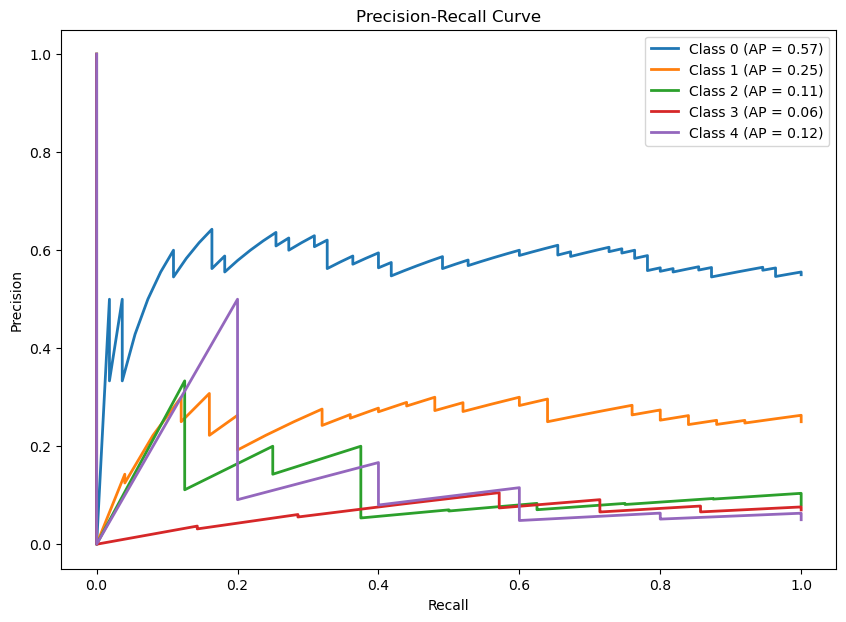

In [22]:
import torch
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt

final_predictions_np = final_predictions.detach().numpy()

precision = dict()
recall = dict()
average_precision = dict()

for i in range(5):
    precision[i], recall[i], _ = precision_recall_curve(true_labels == i, final_predictions_np[:, i])
    average_precision[i] = auc(recall[i], precision[i])

# Plot Precision-Recall curve
plt.figure(figsize=(10, 7))
for i in range(5):
    plt.plot(recall[i], precision[i], lw=2, label=f'Class {i} (AP = {average_precision[i]:0.2f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="best")
plt.show()

In [24]:
from sklearn.metrics import classification_report, accuracy_score

predicted_labels = final_predictions_np.argmax(axis=1)
report = classification_report(true_labels, predicted_labels, target_names=[f'Class {i}' for i in range(5)])
accuracy = accuracy_score(true_labels, predicted_labels)

print("Classification Report:")
print(report)
print(f"Accuracy: {accuracy:.4f}")


Classification Report:
              precision    recall  f1-score   support

     Class 0       0.60      0.65      0.63        55
     Class 1       0.27      0.28      0.27        25
     Class 2       0.33      0.12      0.18         8
     Class 3       0.00      0.00      0.00         7
     Class 4       0.22      0.40      0.29         5

    accuracy                           0.46       100
   macro avg       0.28      0.29      0.27       100
weighted avg       0.44      0.46      0.44       100

Accuracy: 0.4600
